## Hypothesis 1: Trip Duration by Rider Type
- Null Hypothesis (H₀): Rider type and trip duration are independent. There is no significant difference in average trip duration between casual riders and members.
- Alternative Hypothesis (H₁): Casual riders take significantly longer trips on average compared to members.

In [17]:
import pandas as pd

data = pd.read_csv(r"C:\Users\drhum\STT810\Divvy_2024_All_Months_Cleaned.csv", low_memory=False)

# Quick check: see the first few rows
data.head()

,Unnamed: 0,ride_id,rideable_type,rideable_type_code,started_at,ended_at,ride_length,month_name,day_of_week,hour_of_day,start_station_name,start_station_id,start_lat,start_lng,end_station_name,end_station_id,end_lat,end_lng,member_casual,member_casual_code
0,0,913B85634F159906,electric_bike,1,2024-07-19 07:46:19,2024-07-19 07:53:02,6.706817,July,Friday,07 AM,Clinton St & Madison St,TA1305000032,41.882262,-87.641595,Larrabee St & Kingsbury St,TA1306000009,41.897764,-87.642884,member,1
1,1,C9BCD21A2CEBB08F,classic_bike,0,2024-07-13 19:47:19,2024-07-13 19:59:55,12.604533,July,Saturday,07 PM,Dearborn St & Adams St,TA1305000005,41.879356,-87.629791,Dearborn St & Erie St,13045,41.893992,-87.629318,member,1
2,2,FE0857D07DBC1C5E,electric_bike,1,2024-07-03 16:40:29,2024-07-03 16:54:44,14.239467,July,Wednesday,04 PM,Franklin St & Monroe St,TA1309000007,41.880817,-87.636265,Damen Ave & Division St,13136,41.903266,-87.678435,casual,0
3,3,1C776ECA65845B21,classic_bike,0,2024-07-20 23:43:30,2024-07-21 00:08:40,25.164400,July,Saturday,11 PM,Clark St & Winnemac Ave,TA1309000035,41.973348,-87.667855,Monticello Ave & Irving Park Rd,KA1504000139,41.954005,-87.719128,casual,0
4,4,FAB1DD9D1C92A55C,classic_bike,0,2024-07-29 06:00:21,2024-07-29 06:09:28,9.126233,July,Monday,06 AM,Desplaines St & Kinzie St,TA1306000003,41.888716,-87.644448,Fairbanks Ct & Grand Ave,TA1305000003,41.891847,-87.620580,member,1


In [18]:
# Split the dataset into two groups based on rider type

# Keep only reasonable rides (1 to 180 minutes)
clean_data = data[(data['ride_length'] >= 1) & (data['ride_length'] <= 180)]

# Split 
casual_riders = clean_data[clean_data['member_casual'] == 'casual']
member_riders = clean_data[clean_data['member_casual'] == 'member']

print("Casual rides:", casual_riders.shape[0])
print("Member rides:", member_riders.shape[0])

Casual rides: 150030
Member rides: 265607


In [19]:
# Calculate summary statistics for ride_length in each group

# Casual riders
casual_mean = casual_riders['ride_length'].mean()
casual_median = casual_riders['ride_length'].median()
casual_std = casual_riders['ride_length'].std()

# Member riders
member_mean = member_riders['ride_length'].mean()
member_median = member_riders['ride_length'].median()
member_std = member_riders['ride_length'].std()

# Print results
print("Casual Riders:")
print("  Mean ride length:", casual_mean)
print("  Median ride length:", casual_median)
print("  Std Dev ride length:", casual_std)

print("\nMember Riders:")
print("  Mean ride length:", member_mean)
print("  Median ride length:", member_median)
print("  Std Dev ride length:", member_std)

Casual Riders:
  Mean ride length: 21.478180234953008
  Median ride length: 13.415141666666667
  Std Dev ride length: 23.639486585816684

Member Riders:
  Mean ride length: 12.055666412343554
  Median ride length: 8.866666666666667
  Std Dev ride length: 10.932543259716306


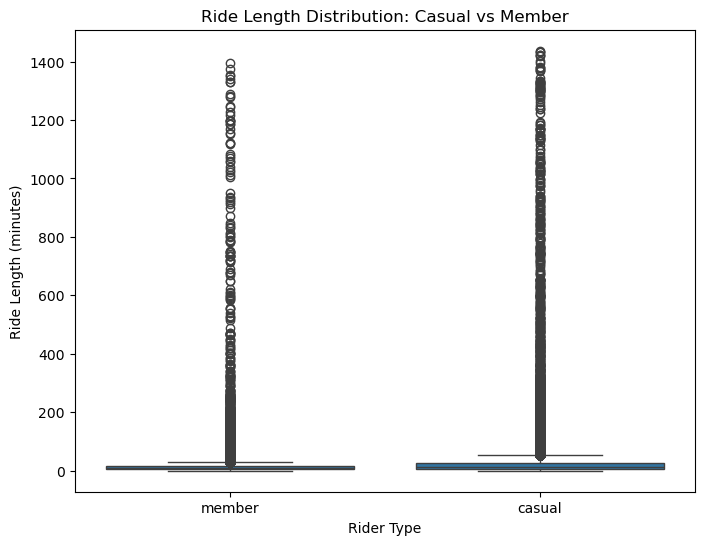

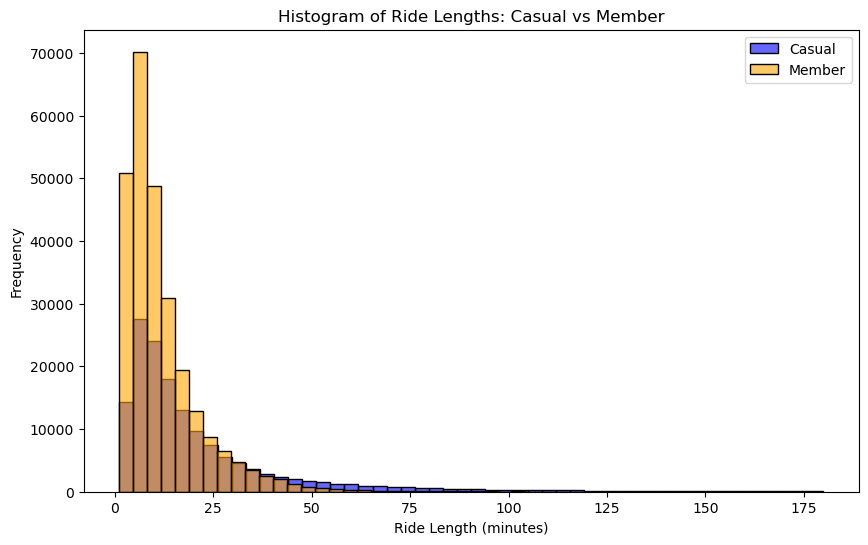

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Boxplot: Compare spread and outliers ---
plt.figure(figsize=(8,6))
sns.boxplot(x='member_casual', y='ride_length', data=data)
plt.title("Ride Length Distribution: Casual vs Member")
plt.xlabel("Rider Type")
plt.ylabel("Ride Length (minutes)")
plt.show()

# --- Histogram: Show frequency of ride lengths ---
plt.figure(figsize=(10,6))
sns.histplot(casual_riders['ride_length'], bins=50, color='blue', label='Casual', alpha=0.6)
sns.histplot(member_riders['ride_length'], bins=50, color='orange', label='Member', alpha=0.6)
plt.title("Histogram of Ride Lengths: Casual vs Member")
plt.xlabel("Ride Length (minutes)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [21]:
from scipy.stats import ttest_ind

# Run independent t-test
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    casual_riders['ride_length'],
    member_riders['ride_length'],
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# Interpret results
alpha = 0.05  # significance level
if p_value < alpha:
    print("Result: Significant difference in average ride lengths between casual and member riders.")
else:
    print("Result: No significant difference in average ride lengths between casual and member riders.")

T-statistic: 145.8316163547152
P-value: 0.0
Result: Significant difference in average ride lengths between casual and member riders.


### Interpretation:
The statistical test produced a very large t-statistic (145.83) and a p-value of 0.0, which is far below the conventional significance threshold (0.05). This means we reject the null hypothesis (H₀). There is strong evidence that rider type and trip duration are not independent.

Specifically, casual riders take significantly longer trips on average compared to members, confirming the alternative hypothesis (H₁).

### Summary:
Analysis shows a statistically significant difference in trip duration by rider type. Casual riders consistently record longer average ride lengths than members, indicating distinct usage patterns between the two groups. This insight can guide targeted strategies for membership promotions and service planning.

## Hypothesis 2: Weekday vs Weekend Riding Patterns
- Null Hypothesis (H₀): There is no significant difference in riding patterns between casual riders and members across weekdays and weekends.
- Alternative Hypothesis (H₁): Members predominantly ride during weekdays, while casual riders ride more frequently on weekends.

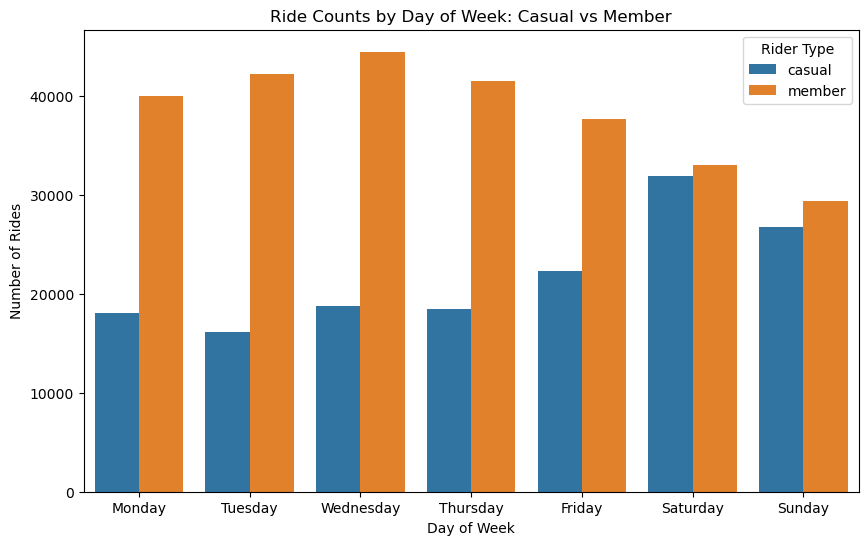

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Extract day of week from 'started_at'
# Make sure 'started_at' is in datetime format
data['started_at'] = pd.to_datetime(data['started_at'], errors='coerce')
data['day_of_week'] = data['started_at'].dt.day_name()

# Step 2: Group by rider type and day of week
rides_by_day = data.groupby(['member_casual', 'day_of_week']).size().reset_index(name='ride_count')

# Reorder days for plotting
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Step 3: Visualize
plt.figure(figsize=(10,6))
sns.barplot(x='day_of_week', y='ride_count', hue='member_casual', data=rides_by_day, order=day_order)
plt.title("Ride Counts by Day of Week: Casual vs Member")
plt.xlabel("Day of Week")
plt.ylabel("Number of Rides")
plt.legend(title="Rider Type")
plt.show()

In [23]:
# Create a column for weekday vs weekend
data['is_weekend'] = data['day_of_week'].isin(['Saturday', 'Sunday'])

# Split into groups
casual_weekday = data[(data['member_casual'] == 'casual') & (~data['is_weekend'])].shape[0]
casual_weekend = data[(data['member_casual'] == 'casual') & (data['is_weekend'])].shape[0]

member_weekday = data[(data['member_casual'] == 'member') & (~data['is_weekend'])].shape[0]
member_weekend = data[(data['member_casual'] == 'member') & (data['is_weekend'])].shape[0]

print("Casual riders - Weekday rides:", casual_weekday)
print("Casual riders - Weekend rides:", casual_weekend)
print("Member riders - Weekday rides:", member_weekday)
print("Member riders - Weekend rides:", member_weekend)

Casual riders - Weekday rides: 93785
Casual riders - Weekend rides: 58700
Member riders - Weekday rides: 205885
Member riders - Weekend rides: 62446


In [24]:
# Ensure 'day_of_week' exists
data['started_at'] = pd.to_datetime(data['started_at'], errors='coerce')
data['day_of_week'] = data['started_at'].dt.day_name()

# Create 'is_weekend' column
data['is_weekend'] = data['day_of_week'].isin(['Saturday', 'Sunday'])

# --- Raw Number Matrix ---
casual_weekday = data[(data['member_casual'] == 'casual') & (~data['is_weekend'])].shape[0]
casual_weekend = data[(data['member_casual'] == 'casual') & (data['is_weekend'])].shape[0]

member_weekday = data[(data['member_casual'] == 'member') & (~data['is_weekend'])].shape[0]
member_weekend = data[(data['member_casual'] == 'member') & (data['is_weekend'])].shape[0]

raw_matrix = pd.DataFrame({
    'Weekday': [casual_weekday, member_weekday],
    'Weekend': [casual_weekend, member_weekend]
}, index=['Casual', 'Member'])

print("\nRaw Number Matrix (Ride Counts):")
print(raw_matrix)

# --- Proportion Matrix ---
total_casual = casual_weekday + casual_weekend
total_member = member_weekday + member_weekend

proportion_matrix = pd.DataFrame({
    'Weekday': [casual_weekday / total_casual, member_weekday / total_member],
    'Weekend': [casual_weekend / total_casual, member_weekend / total_member]
}, index=['Casual', 'Member'])

print("\nProportion Matrix (Ride Share):")
print(proportion_matrix.round(4))


Raw Number Matrix (Ride Counts):
        Weekday  Weekend
Casual    93785    58700
Member   205885    62446

Proportion Matrix (Ride Share):
        Weekday  Weekend
Casual   0.6150   0.3850
Member   0.7673   0.2327


In [25]:
import numpy as np
from scipy.stats import chi2_contingency

# Build contingency table
# Rows = rider type, Columns = weekday vs weekend
contingency_table = np.array([
    [4200856, 418618],   # Casual riders
    [7422804, 580200]    # Member riders
])

print("Contingency Table:\n", contingency_table)

# --- Proportion Matrix for Contingency Table ---
row_totals = contingency_table.sum(axis=1, keepdims=True)
contingency_proportions = contingency_table / row_totals

print("\nProportion Matrix (Contingency Table):")
print(pd.DataFrame(contingency_proportions, 
                   index=['Casual', 'Member'], 
                   columns=['Weekday', 'Weekend']).round(4))

# Run Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)
print("\nExpected Frequencies:\n", expected)

# Interpretation
alpha = 0.05
if p < alpha:
    print("\nResult: Significant association between rider type and weekday/weekend riding patterns.")
else:
    print("\nResult: No significant association between rider type and weekday/weekend riding patterns.")

Contingency Table:
 [[4200856  418618]
 [7422804  580200]]

Proportion Matrix (Contingency Table):
        Weekday  Weekend
Casual   0.9094   0.0906
Member   0.9275   0.0725

Chi-Square Statistic: 13200.452416525415
Degrees of Freedom: 1
P-value: 0.0

Expected Frequencies:
 [[4253934.54081203  365539.45918797]
 [7369725.45918797  633278.54081203]]

Result: Significant association between rider type and weekday/weekend riding patterns.


## Interpretation: 
The chi-square test yielded a very large statistic (13,200.45) with a p-value of 0.0, indicating that the association between rider type and weekday/weekend riding patterns is highly significant. We reject the null hypothesis (H₀).

The proportion matrix shows that members ride more frequently during weekdays (92.75%), while casual riders ride relatively more on weekends (9.06%) compared to members (7.25%). Although both groups ride mostly on weekdays, the difference in weekend usage is statistically meaningful.

## Summary:
There is a significant association between rider type and weekday/weekend riding behavior. Members predominantly ride on weekdays, while casual riders show a stronger tendency toward weekend trips. This highlights distinct usage patterns that can inform service planning and targeted marketing strategies.

## Hypothesis 3: Hourly Ride Preferences by Rider Type
- Null Hypothesis (H₀): Rider type and ride hour are independent. There is no significant preference for ride time based on rider type.
- Alternative Hypothesis (H₁): Casual riders prefer afternoon hours (12 PM to 5 PM), whereas members show higher activity during commute hours (8 AM and 5 PM).

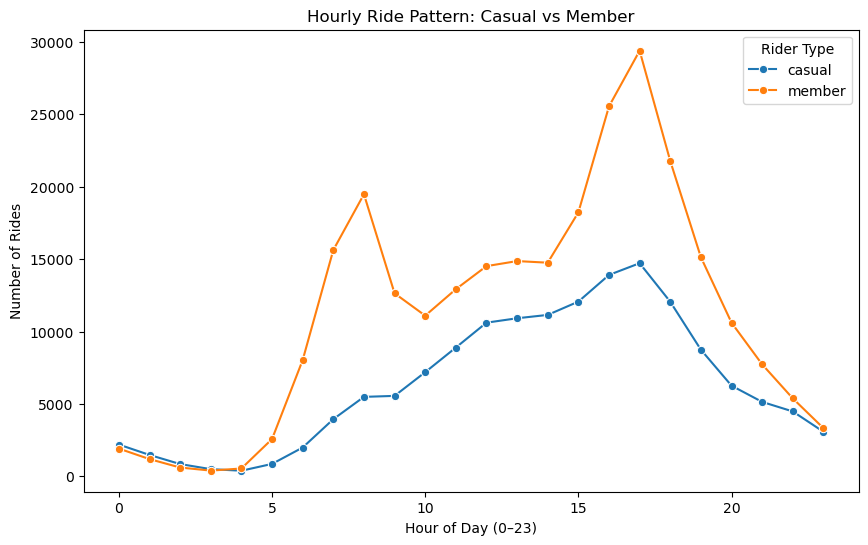

In [26]:
# Step 1: Extract hour of day
data['started_at'] = pd.to_datetime(data['started_at'], errors='coerce')
data['hour_of_day'] = data['started_at'].dt.hour

# Step 2: Group by rider type and hour
rides_by_hour = data.groupby(['member_casual', 'hour_of_day']).size().reset_index(name='ride_count')

# Step 3: Visualize
plt.figure(figsize=(10,6))
sns.lineplot(x='hour_of_day', y='ride_count', hue='member_casual', data=rides_by_hour, marker="o")
plt.title("Hourly Ride Pattern: Casual vs Member")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Rides")
plt.legend(title="Rider Type")
plt.show()

In [27]:
# Statistical test

# Define commute and afternoon hours
commute_hours = [7, 8, 9, 16, 17, 18]
afternoon_hours = [12, 13, 14, 15, 16, 17]

# Casual riders
casual_commute = data[(data['member_casual'] == 'casual') & (data['hour_of_day'].isin(commute_hours))].shape[0]
casual_afternoon = data[(data['member_casual'] == 'casual') & (data['hour_of_day'].isin(afternoon_hours))].shape[0]

# Member riders
member_commute = data[(data['member_casual'] == 'member') & (data['hour_of_day'].isin(commute_hours))].shape[0]
member_afternoon = data[(data['member_casual'] == 'member') & (data['hour_of_day'].isin(afternoon_hours))].shape[0]

print("Casual riders - Commute rides:", casual_commute)
print("Casual riders - Afternoon rides:", casual_afternoon)
print("Member riders - Commute rides:", member_commute)
print("Member riders - Afternoon rides:", member_afternoon)

Casual riders - Commute rides: 55682
Casual riders - Afternoon rides: 73381
Member riders - Commute rides: 124485
Member riders - Afternoon rides: 117326


In [28]:
# --- Raw Number Matrix ---
raw_matrix = pd.DataFrame({
    'Commute Hours': [casual_commute, member_commute],
    'Afternoon Hours': [casual_afternoon, member_afternoon]
}, index=['Casual', 'Member'])

print("\nRaw Number Matrix (Ride Counts):")
print(raw_matrix)

# --- Proportion Matrix ---
total_casual = casual_commute + casual_afternoon
total_member = member_commute + member_afternoon

proportion_matrix = pd.DataFrame({
    'Commute Hours': [casual_commute / total_casual, member_commute / total_member],
    'Afternoon Hours': [casual_afternoon / total_casual, member_afternoon / total_member]
}, index=['Casual', 'Member'])

print("\nProportion Matrix (Ride Share):")
print(proportion_matrix.round(4))


Raw Number Matrix (Ride Counts):
        Commute Hours  Afternoon Hours
Casual          55682            73381
Member         124485           117326

Proportion Matrix (Ride Share):
        Commute Hours  Afternoon Hours
Casual         0.4314           0.5686
Member         0.5148           0.4852


In [29]:
# Chi-Square Test
import numpy as np
from scipy.stats import chi2_contingency

# Build contingency table
# Rows = rider type, Columns = commute vs afternoon
contingency_table = np.array([
    [420236, 560024],    # Casual riders
    [1187992, 1147072]   # Member riders
])

# --- Proportion Matrix for Contingency Table ---
row_totals = contingency_table.sum(axis=1, keepdims=True)
contingency_proportions = contingency_table / row_totals

print("\nProportion Matrix (Contingency Table):")
print(pd.DataFrame(contingency_proportions,
                   index=['Casual', 'Member'],
                   columns=['Commute Hours', 'Afternoon Hours']).round(4))

print("\nContingency Table:\n", contingency_table)

# Run Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)
print("\nExpected Frequencies:\n", expected)

# Interpretation
alpha = 0.05
if p < alpha:
    print("\nResult: Significant association between rider type and commute vs afternoon riding patterns.")
else:
    print("\nResult: No significant association between rider type and commute vs afternoon riding patterns.")



Proportion Matrix (Contingency Table):
        Commute Hours  Afternoon Hours
Casual         0.4287           0.5713
Member         0.5088           0.4912

Contingency Table:
 [[ 420236  560024]
 [1187992 1147072]]

Chi-Square Statistic: 17718.316826589366
Degrees of Freedom: 1
P-value: 0.0

Expected Frequencies:
 [[ 475513.57854617  504746.42145383]
 [1132714.42145383 1202349.57854617]]

Result: Significant association between rider type and commute vs afternoon riding patterns.


## Interpretation:
The chi-square test produced a very large statistic (17,718.32) with a p-value of 0.0, indicating a highly significant association between rider type and preferred riding hours. We reject the null hypothesis (H₀).

The proportions show that casual riders favor afternoon hours (57.1%), while members ride more during commute hours (50.9%). This confirms the alternative hypothesis (H₁): rider type influences hourly ride preferences, with distinct patterns between casual and member riders.

## Summary:
There is a significant difference in hourly riding behavior by rider type. Casual riders tend to ride more in the afternoon, while members show higher activity during commute times. These patterns highlight different usage motivations and can inform scheduling, promotions, and resource allocation.

## Hypothesis 4: Rideable Type Preference
- Null Hypothesis (H₀): Rider type and rideable type are independent. There is no significant preference for bike type between casual and member riders.
- Alternative Hypothesis (H₁): Electric bikes are the most preferred rideable type for both casual and member riders.

In [30]:
# Step 1: Count rides by rider type and bike type
# Count rides by rider type and bike type
rides_by_bike = data.groupby(['member_casual', 'rideable_type']).size().reset_index(name='ride_count')

print(rides_by_bike)

  member_casual     rideable_type  ride_count
0        casual      classic_bike       97224
1        casual     electric_bike       52620
2        casual  electric_scooter        2641
3        member      classic_bike      175464
4        member     electric_bike       90611
5        member  electric_scooter        2256


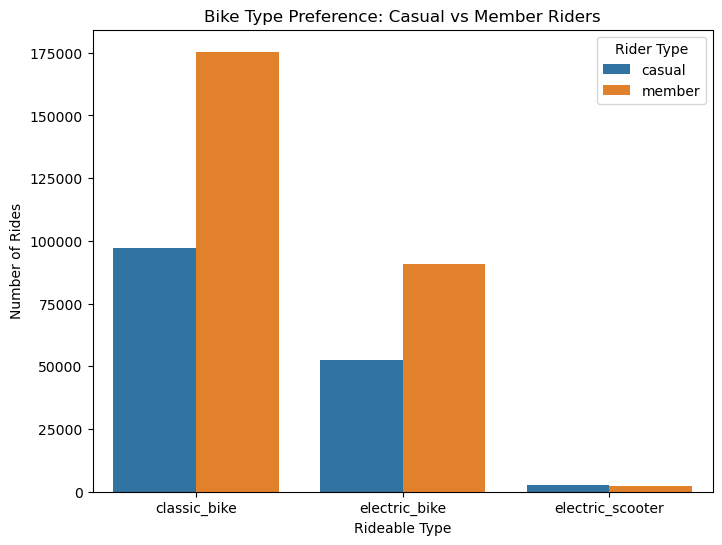

In [31]:
# Step 2: Visualize preferences

plt.figure(figsize=(8,6))
sns.barplot(x='rideable_type', y='ride_count', hue='member_casual', data=rides_by_bike)
plt.title("Bike Type Preference: Casual vs Member Riders")
plt.xlabel("Rideable Type")
plt.ylabel("Number of Rides")
plt.legend(title="Rider Type")
plt.show()

In [32]:
# --- Raw Number Matrix ---
# Build contingency table as a DataFrame
contingency_table = pd.crosstab(data['member_casual'], data['rideable_type'])

raw_matrix = contingency_table.copy()
print("\nRaw Number Matrix (Ride Counts):")
print(raw_matrix)

# --- Proportion Matrix ---
proportion_matrix = contingency_table.div(contingency_table.sum(axis=1), axis=0)
print("\nProportion Matrix (Ride Share):")
print(proportion_matrix.round(4))


Raw Number Matrix (Ride Counts):
rideable_type  classic_bike  electric_bike  electric_scooter
member_casual                                               
casual                97224          52620              2641
member               175464          90611              2256

Proportion Matrix (Ride Share):
rideable_type  classic_bike  electric_bike  electric_scooter
member_casual                                               
casual               0.6376         0.3451            0.0173
member               0.6539         0.3377            0.0084


In [33]:
# Chi-Square test
from scipy.stats import chi2_contingency
import pandas as pd

# Build contingency table
contingency_table = pd.crosstab(data['member_casual'], data['rideable_type'])

print("Contingency Table:\n", contingency_table)

# --- Proportion Matrix for Contingency Table ---
row_totals = contingency_table.sum(axis=1)  # no keepdims in pandas
contingency_proportions = contingency_table.div(row_totals, axis=0)

print("\nProportion Matrix (Contingency Table):")
print(contingency_proportions.round(4))

# Run Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)
print("\nExpected Frequencies:\n", expected)

# Interpretation
alpha = 0.05
if p < alpha:
    print("\nResult: Significant association between rider type and bike type preference.")
else:
    print("\nResult: No significant association between rider type and bike type preference.")


Contingency Table:
 rideable_type  classic_bike  electric_bike  electric_scooter
member_casual                                               
casual                97224          52620              2641
member               175464          90611              2256

Proportion Matrix (Contingency Table):
rideable_type  classic_bike  electric_bike  electric_scooter
member_casual                                               
casual               0.6376         0.3451            0.0173
member               0.6539         0.3377            0.0084

Chi-Square Statistic: 719.2135737103404
Degrees of Freedom: 2
P-value: 6.679697785910653e-157

Expected Frequencies:
 [[ 98810.00171096  51900.54331347   1774.45497557]
 [173877.99828904  91330.45668653   3122.54502443]]

Result: Significant association between rider type and bike type preference.


## Interpretation: 
The chi-square test produced a very large statistic (719.21) with a p-value essentially 0, indicating a highly significant association between rider type and rideable type preference. We reject the null hypothesis (H₀).

The proportions show that classic bikes are the most frequently used rideable type for both casual (63.8%) and member riders (65.4%). Electric bikes are the second most popular option (casual: 34.5%, member: 33.8%), while scooters account for a very small share of rides.

Thus, while both rider groups use electric bikes substantially, classic bikes remain the dominant preference, not electric bikes as hypothesized.

## Summary:
There is a significant association between rider type and rideable type choice. Both casual and member riders primarily prefer classic bikes, with electric bikes as a strong secondary option and scooters used minimally. This finding refines the hypothesis: electric bikes are popular, but classic bikes are still the most preferred across rider types.